# AAV5 -- Filtre "sel" (second filtre, pendant du filtre "viab")

Le filtre existant (`AAV5_SEL_sorting.ipynb`, deplace dans `obsolete/`) borne
`compte_plasmide` -- le **denominateur** du ratio `viab = log2(virus / plasmide)` -- pour retirer
le bruit a faible profondeur et la contamination 7m8 a forte profondeur. On l'appelle **`viab`**
a partir de ce notebook.

Ce notebook construit son **pendant pour la selectivite**, appele **`sel`** : au lieu de borner
`compte_plasmide`, on borne **`compte_virus`** -- le denominateur du ratio
`sel_org_i = log2(organoide_i_adn / virus)` -- exactement le meme role structurel que
`compte_plasmide` pour `viab` (l'"entree" bruitee/contaminee de l'etape suivante).

Deux temps, comme convenu :

1. **Filtre `sel` (virus seul)** -- meme logique que `viab` : borne `compte_virus`, retire le
   7m8 (hamming <= 2, contamination confirmee sur plasmide ET virus dans le notebook `viab`).
   Un seul filtre, partage par `sel_org1`/`sel_org2`/`sel_org3` (comme le filtre `viab` l'est deja
   par les 4 cibles).
2. **Extension `sel_org2`** -- empile en plus un seuil sur `compte_organoide_2_adn` (le
   numerateur), focus sur `sel_org2` specifiquement (la cible qui donne systematiquement le
   meilleur signal cette session, cf. `AAV5_SEL_potts_readout_depth.ipynb` /
   `AAV5_SEL_deep_profile_model_sel_org2.ipynb`).

**Aucun seuil n'est fixe a l'avance.** Les valeurs `VIRUS_MIN`/`VIRUS_MAX`/`ORG2_MIN` posees plus
bas sont des points de depart (informes par les percentiles calcules dans ce notebook), a ajuster
a tatons en regardant les tables/graphes de balayage -- meme methode que les sections 6/7 du
notebook `viab`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --- locate the confidential AAV5 organoid CSV (never commit / push / upload) ---
CSV_PATH = Path("AAV5_organoides.csv")
if not CSV_PATH.exists():
    here = Path.cwd()
    root = next(p for p in [here, *here.parents] if p.name == "Modelization_V2")
    CSV_PATH = root / "notebooks/notebooks/Selectivity/AAV5/AAV5_organoides.csv"
assert CSV_PATH.exists(), CSV_PATH

count_cols = [
    "compte_plasmide", "compte_virus",
    "compte_organoide_1_adn", "compte_organoide_1_arn",
    "compte_organoide_2_adn", "compte_organoide_2_arn",
    "compte_organoide_3_adn", "compte_organoide_3_arn",
]
log2_cols = [c for c in pd.read_csv(CSV_PATH, nrows=0).columns if c.startswith("log2_")]
dtypes = {"sequence": "string",
          **{c: "float32" for c in count_cols},
          **{c: "float32" for c in log2_cols}}

df = pd.read_csv(CSV_PATH, dtype=dtypes)
df["sequence"] = df["sequence"].astype("string")
print(df.shape)

viab_col = "log2_enrichissement_virus_sur_plasmide"
sel_cols = [f"log2_enrichissement_organoide_{i}_adn_sur_virus" for i in (1, 2, 3)]
SEL_ORG2_COL = sel_cols[1]

# Hamming distance to the 7m8 spike-in (LGETTRP) -- meme calcul que le notebook viab.
WT = "LGETTRP"
char = np.frombuffer("".join(df["sequence"]).encode("ascii"), np.uint8).reshape(len(df), 7)
ham = (char != np.frombuffer(WT.encode(), np.uint8)).sum(axis=1).astype(np.int16)
df["hamming_to_7m8"] = ham
not_7m8 = ham > 2  # meme retrait que le filtre viab (HAM_MAX=2)
print(f"variants a hamming <= 2 du 7m8 (retires) : {int((~not_7m8).sum()):,}")

(5595543, 35)


variants a hamming <= 2 du 7m8 (retires) : 274


## 1. Distribution brute de `compte_virus` et `compte_organoide_2_adn`

Rappel (deja etabli dans `AAV5_SEL_analysis.ipynb` section 1b) : le filtre `viab` existant ne
touche jamais `compte_virus` -- sa distribution est identique avant/apres ce filtre. C'est
exactement ce qu'on s'apprete a borner ici.

compte_virus -- percentiles [0,1,5,10,25,50,75,90,95,99,99.9,100]:
[5.0000000e-01 5.0000000e-01 5.0000000e-01 5.0000000e-01 1.0000000e+00
 7.0000000e+00 2.1000000e+01 4.5000000e+01 7.3000000e+01 3.6650000e+02
 2.6922000e+03 3.0438325e+06]

compte_organoide_2_adn -- 486,844 lignes non-nulles / 5,595,543 (8.7%)
percentiles parmi les non-nulles [1,5,10,25,50,75,90,95,99,99.9,100]:
[5.0000000e-01 1.0000000e+00 2.0000000e+00 6.0000000e+00 1.7500000e+01
 3.8500000e+01 1.0000000e+02 2.3050000e+02 1.2593000e+03 7.7658000e+03
 2.4466225e+06]


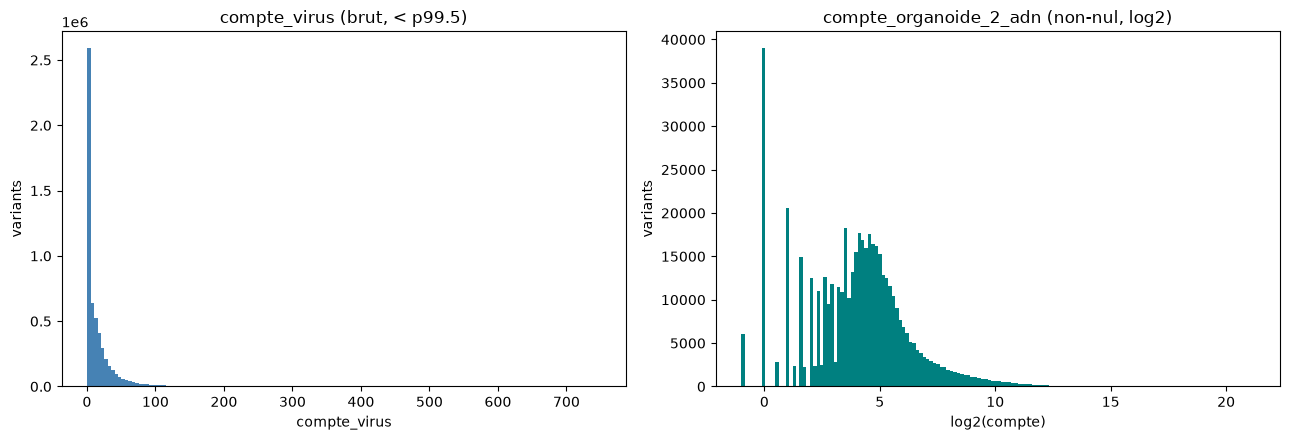

In [2]:
virus = df["compte_virus"].to_numpy(np.float64)
org2 = df["compte_organoide_2_adn"].to_numpy(np.float64)

print("compte_virus -- percentiles [0,1,5,10,25,50,75,90,95,99,99.9,100]:")
print(np.round(np.percentile(virus, [0, 1, 5, 10, 25, 50, 75, 90, 95, 99, 99.9, 100]), 1))

nz = org2[org2 > 0]
print(f"\ncompte_organoide_2_adn -- {nz.size:,} lignes non-nulles / {len(df):,} "
      f"({nz.size / len(df):.1%})")
print("percentiles parmi les non-nulles [1,5,10,25,50,75,90,95,99,99.9,100]:")
print(np.round(np.percentile(nz, [1, 5, 10, 25, 50, 75, 90, 95, 99, 99.9, 100]), 1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(virus[(virus > 0) & (virus < np.percentile(virus, 99.5))], bins=150, color="steelblue")
axes[0].set(title="compte_virus (brut, < p99.5)", xlabel="compte_virus", ylabel="variants")
axes[1].hist(np.log2(nz), bins=150, color="teal")
axes[1].set(title="compte_organoide_2_adn (non-nul, log2)", xlabel="log2(compte)", ylabel="variants")
plt.tight_layout(); plt.show()

## 2. Balayage du seuil sur `compte_virus` (diversite conservee)

Meme methode que les sections 6/7 du notebook `viab` : borne basse balayee seule, puis fenetre
basse+haute. On suit en parallele la diversite totale ET le nombre de lignes `sel_org2` finies
conservees (`compte_organoide_2_adn > 0` ET `compte_virus` dans la fenetre), puisque c'est la
cible qui nous interesse en premier.

,diversite,frac_vs_brut,sel_org2_finite_conservees
virus_min,,,
1,5032398,0.8994,476211
2,3731649,0.6669,437287
5,3094391,0.5530,394225
10,2430410,0.4343,346539
20,1473133,0.2633,273142
50,483574,0.0864,169128
100,184931,0.0330,112523
200,93419,0.0167,75816
500,42044,0.0075,39115


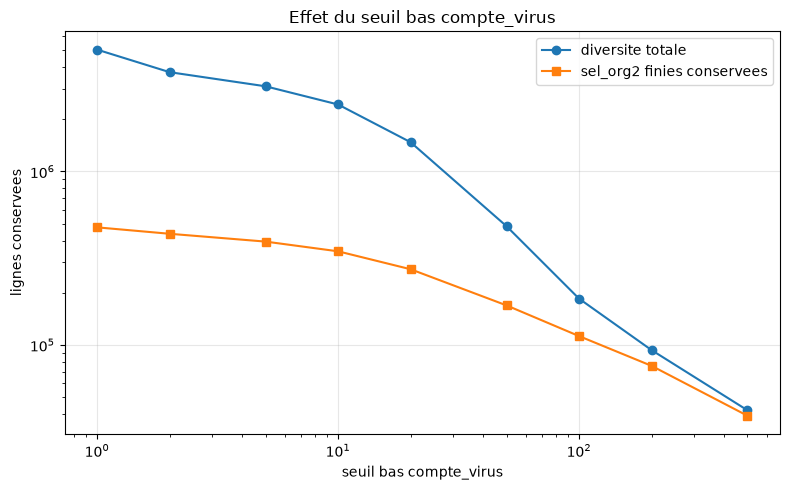

In [3]:
org2_finite = org2 > 0  # log2(organoide/virus) fini cote numerateur

VIRUS_MIN_GRID = np.array([1, 2, 5, 10, 20, 50, 100, 200, 500])
rows = []
for thr in VIRUS_MIN_GRID:
    k = not_7m8 & (virus >= thr)
    rows.append({
        "virus_min": int(thr),
        "diversite": int(k.sum()),
        "frac_vs_brut": round(int(k.sum()) / len(df), 4),
        "sel_org2_finite_conservees": int((k & org2_finite).sum()),
    })
sweep_lo = pd.DataFrame(rows).set_index("virus_min")
display(sweep_lo)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sweep_lo.index, sweep_lo["diversite"], "o-", label="diversite totale")
ax.plot(sweep_lo.index, sweep_lo["sel_org2_finite_conservees"], "s-", label="sel_org2 finies conservees")
ax.set(xscale="log", yscale="log", xlabel="seuil bas compte_virus",
       ylabel="lignes conservees", title="Effet du seuil bas compte_virus")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [4]:
# Fenetre haute : la traine de compte_virus monte a ~3e6 (meme profil de contamination que
# compte_plasmide pour le filtre viab) -- borne basse fixee a un point intermediaire de la grille
# ci-dessus (5, a ajuster ensemble) pendant qu'on balaye la borne haute.
VIRUS_MIN_FOR_UPPER_SWEEP = 5
VIRUS_MAX_GRID = np.array([500, 1000, 2000, 3000, 5000, 10_000, 50_000])

lo_fixed = not_7m8 & (virus >= VIRUS_MIN_FOR_UPPER_SWEEP)
print(f"virus >= {VIRUS_MIN_FOR_UPPER_SWEEP} (hamming > 2) : {int(lo_fixed.sum()):,} lignes")

rows = []
for up in VIRUS_MAX_GRID:
    k = lo_fixed & (virus <= up)
    rows.append({
        "virus_max": int(up),
        "diversite": int(k.sum()),
        "n_retirees_par_la_borne_haute": int(lo_fixed.sum()) - int(k.sum()),
        "sel_org2_finite_conservees": int((k & org2_finite).sum()),
    })
sweep_hi = pd.DataFrame(rows).set_index("virus_max")
display(sweep_hi)

virus >= 5 (hamming > 2) : 3,094,391 lignes


,diversite,n_retirees_par_la_borne_haute,sel_org2_finite_conservees
virus_max,,,
500,3052381,42010,355141
1000,3074093,20298,374365
2000,3085787,8604,385656
3000,3089600,4791,389445
5000,3092351,2040,392186
10000,3093826,565,393660
50000,3094375,16,394209


## 3. CSV de travail -- filtre `sel` (virus seul)

Seuils de depart ci-dessous -- **a valider/ajuster ensemble** au vu des tables de la section 2
(le coude dans `sel_org2_finite_conservees` est le signal a regarder, comme le "trou" du
classement plasmide avait guide `PLASMID_MIN`/`PLASMID_MAX` pour `viab`).

In [5]:
# --- PLACEHOLDER : premier essai, a tatons ---
VIRUS_MIN = 5      # cf. sweep_lo -- garde l'essentiel de la diversite sel_org2 (perte marginale sous 5)
VIRUS_MAX = 5000   # cf. sweep_hi -- coupe la queue de contamination, perte de diversite negligeable

pl_virus_keep = not_7m8 & (virus >= VIRUS_MIN) & (virus <= VIRUS_MAX)

N = len(df)
print(f"variants initiaux                         : {N:,}")
print(f"  retires hamming <= 2 (7m8)               : {int((~not_7m8).sum()):,}")
print(f"  retires virus hors [{VIRUS_MIN}, {VIRUS_MAX}]           : "
      f"{int((not_7m8 & ~((virus >= VIRUS_MIN) & (virus <= VIRUS_MAX))).sum()):,}")
print(f"variants conserves (CSV de travail sel)   : {int(pl_virus_keep.sum()):,}  "
      f"({pl_virus_keep.mean():.1%})")
print(f"  dont sel_org2 finies                     : {int((pl_virus_keep & org2_finite).sum()):,}")

df_sorted_sel = df.loc[pl_virus_keep].drop(columns=["hamming_to_7m8"]).reset_index(drop=True)

OUT_SEL = CSV_PATH.with_name("AAV5_organoides_sorted_sel.csv")
df_sorted_sel.to_csv(OUT_SEL, index=False)
print(f"ecrit {OUT_SEL.name}  ({df_sorted_sel.shape[0]:,} lignes x {df_sorted_sel.shape[1]} colonnes)")

variants initiaux                         : 5,595,543
  retires hamming <= 2 (7m8)               : 274
  retires virus hors [5, 5000]           : 2,502,918
variants conserves (CSV de travail sel)   : 3,092,351  (55.3%)
  dont sel_org2 finies                     : 392,186


ecrit AAV5_organoides_sorted_sel.csv  (3,092,351 lignes x 35 colonnes)


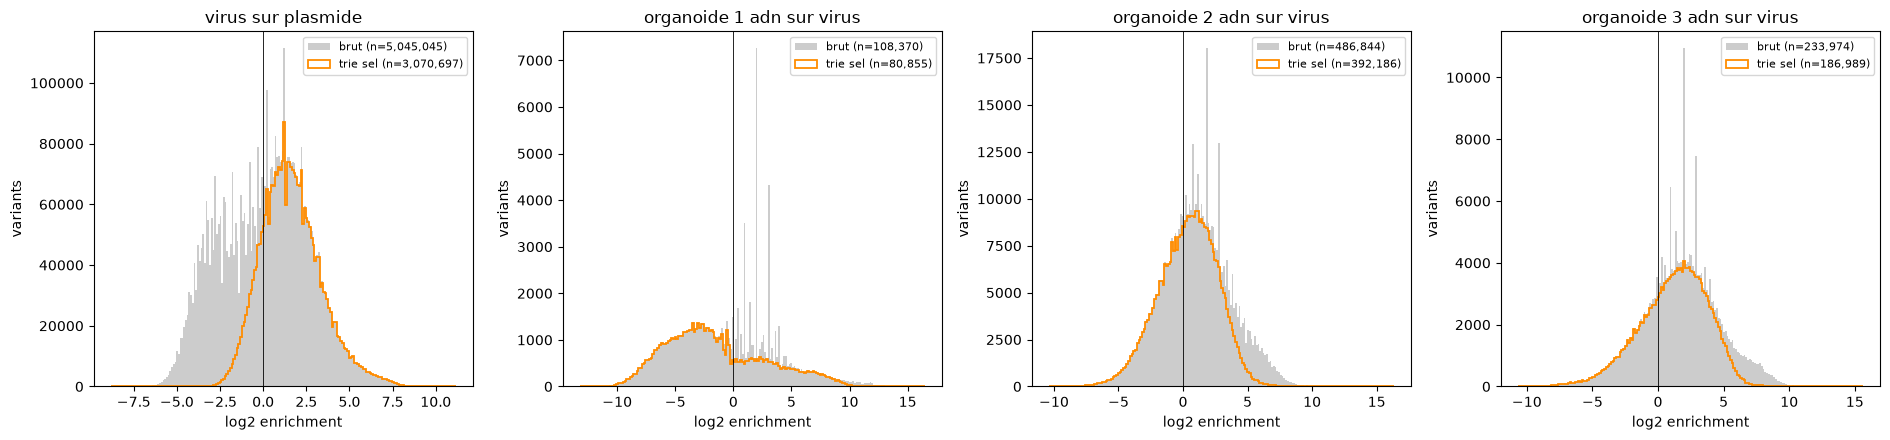

In [6]:
# Effet du filtre sur les distributions de log enrichment (avant / apres)
fig, axes = plt.subplots(1, 4, figsize=(19, 4.5))
for ax, col in zip(axes, [viab_col, *sel_cols]):
    a = df[col].to_numpy(np.float64);            a = a[np.isfinite(a)]
    b = df_sorted_sel[col].to_numpy(np.float64);  b = b[np.isfinite(b)]
    bins = np.histogram_bin_edges(a, bins=200)
    ax.hist(a, bins=bins, color="0.8", label=f"brut (n={a.size:,})")
    ax.hist(b, bins=bins, histtype="step", color="darkorange", lw=1.3, label=f"trie sel (n={b.size:,})")
    ax.axvline(0, color="k", lw=0.6)
    ax.set(title=col.replace("log2_enrichissement_", "").replace("_", " "),
           xlabel="log2 enrichment", ylabel="variants")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4. Extension -- ajout d'un seuil sur `compte_organoide_2_adn` (focus `sel_org2`)

Empile un second seuil, cette fois sur le **numerateur** du ratio `sel_org2`, par-dessus le
filtre virus de la section 3. Balayage d'abord (diversite conservee), puis CSV de travail dedie.

,sel_org2_finite_conservees,frac_vs_sel_virus_only
org2_min,,
0,392186,1.0000
1,390143,0.9948
2,365290,0.9314
5,324206,0.8267
10,274871,0.7009
20,195424,0.4983
50,85224,0.2173
100,45325,0.1156


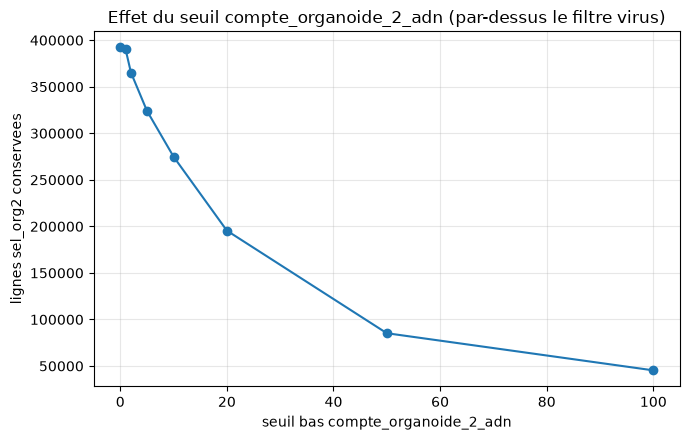

In [7]:
ORG2_MIN_GRID = np.array([0, 1, 2, 5, 10, 20, 50, 100])

rows = []
for thr in ORG2_MIN_GRID:
    k = pl_virus_keep & (org2 >= thr) & org2_finite
    rows.append({
        "org2_min": int(thr),
        "sel_org2_finite_conservees": int(k.sum()),
        "frac_vs_sel_virus_only": round(int(k.sum()) / int((pl_virus_keep & org2_finite).sum()), 4),
    })
sweep_org2 = pd.DataFrame(rows).set_index("org2_min")
display(sweep_org2)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(sweep_org2.index, sweep_org2["sel_org2_finite_conservees"], "o-")
ax.set(xlabel="seuil bas compte_organoide_2_adn", ylabel="lignes sel_org2 conservees",
       title="Effet du seuil compte_organoide_2_adn (par-dessus le filtre virus)")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

variants conserves (filtre virus seul)     : 3,092,351
  dont sel_org2 finies                     : 392,186
variants conserves (+ org2 >= 2)           : 365,290
  dont sel_org2 finies                     : 365,290


ecrit AAV5_organoides_sorted_sel_org2.csv  (365,290 lignes x 35 colonnes)


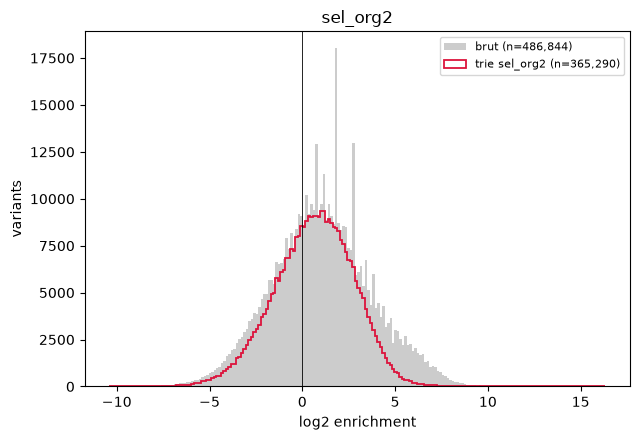

In [8]:
# --- PLACEHOLDER : premier essai, a tatons ---
ORG2_MIN = 2   # cf. sweep_org2 -- a ajuster ensemble

pl_org2_keep = pl_virus_keep & (org2 >= ORG2_MIN)

print(f"variants conserves (filtre virus seul)     : {int(pl_virus_keep.sum()):,}")
print(f"  dont sel_org2 finies                     : {int((pl_virus_keep & org2_finite).sum()):,}")
print(f"variants conserves (+ org2 >= {ORG2_MIN})           : {int(pl_org2_keep.sum()):,}")
print(f"  dont sel_org2 finies                     : {int((pl_org2_keep & org2_finite).sum()):,}")

df_sorted_sel_org2 = df.loc[pl_org2_keep].drop(columns=["hamming_to_7m8"]).reset_index(drop=True)

OUT_ORG2 = CSV_PATH.with_name("AAV5_organoides_sorted_sel_org2.csv")
df_sorted_sel_org2.to_csv(OUT_ORG2, index=False)
print(f"ecrit {OUT_ORG2.name}  ({df_sorted_sel_org2.shape[0]:,} lignes x {df_sorted_sel_org2.shape[1]} colonnes)")

fig, ax = plt.subplots(figsize=(6.5, 4.5))
a = df[SEL_ORG2_COL].to_numpy(np.float64);              a = a[np.isfinite(a)]
b = df_sorted_sel_org2[SEL_ORG2_COL].to_numpy(np.float64); b = b[np.isfinite(b)]
bins = np.histogram_bin_edges(a, bins=200)
ax.hist(a, bins=bins, color="0.8", label=f"brut (n={a.size:,})")
ax.hist(b, bins=bins, histtype="step", color="crimson", lw=1.3, label=f"trie sel_org2 (n={b.size:,})")
ax.axvline(0, color="k", lw=0.6)
ax.set(title="sel_org2", xlabel="log2 enrichment", ylabel="variants")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 5. Filtre alternatif -- intersection org2/org3 (minus 7-mers)

Meme logique que `AAV5_SEL_potts_readout_depth.ipynb` : au lieu de seuiller un comptage brut (ou
sa version ponderee -- testee et ecartee dans `AAV5_SEL_profile_model_sel_org2_invvar.ipynb`, la
ponderation inverse-variance non bornee etait dominee par quelques lignes a comptage enorme,
probablement de la contamination), on utilise **l'accord entre replicats** comme critere de
fiabilite : un variant avec au moins 1 read sur **org2 ET org3** (intersection, pas juste org2
seul) est plus credible qu'un variant qui n'apparait que sur un seul des deux -- ca ne tranche pas
"bruit vs signal fort" a un seuil de magnitude arbitraire, ca demande une validation independante.

Filtre : `compte_organoide_2_adn > 0` ET `compte_organoide_3_adn > 0`, moins le 7m8
(hamming <= 2, meme retrait que partout ailleurs). org1 exclu (deja identifie comme outlier dans
`AAV5_SEL_potts_readout_depth.ipynb`).

In [9]:
org3 = df["compte_organoide_3_adn"].to_numpy(np.float64)  # deja charge (count_cols, cellule 1)

inter_keep = not_7m8 & (org2 > 0) & (org3 > 0)

N = len(df)
print(f"variants initiaux                          : {N:,}")
print(f"  org2 > 0                                  : {int((org2 > 0).sum()):,}")
print(f"  org3 > 0                                  : {int((org3 > 0).sum()):,}")
print(f"  org2 > 0 ET org3 > 0 (intersection)        : {int(((org2 > 0) & (org3 > 0)).sum()):,}")
print(f"  retires hamming <= 2 (7m8)                 : {int((~not_7m8).sum()):,}")
print(f"variants conserves (CSV de travail inter.)  : {int(inter_keep.sum()):,}  ({inter_keep.mean():.1%})")

df_sorted_inter = df.loc[inter_keep].drop(columns=["hamming_to_7m8"]).reset_index(drop=True)

OUT_INTER = CSV_PATH.with_name("AAV5_organoides_sorted_sel_org2org3.csv")
df_sorted_inter.to_csv(OUT_INTER, index=False)
print(f"ecrit {OUT_INTER.name}  ({df_sorted_inter.shape[0]:,} lignes x {df_sorted_inter.shape[1]} colonnes)")

variants initiaux                          : 5,595,543
  org2 > 0                                  : 486,844
  org3 > 0                                  : 233,974
  org2 > 0 ET org3 > 0 (intersection)        : 146,633
  retires hamming <= 2 (7m8)                 : 274
variants conserves (CSV de travail inter.)  : 146,589  (2.6%)


ecrit AAV5_organoides_sorted_sel_org2org3.csv  (146,589 lignes x 35 colonnes)


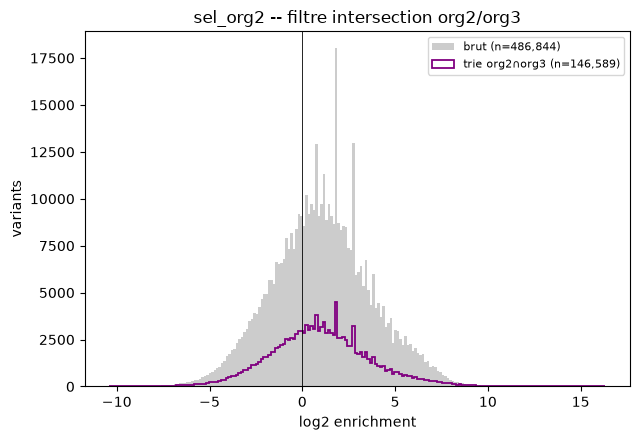

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
a = df[SEL_ORG2_COL].to_numpy(np.float64);                    a = a[np.isfinite(a)]
b = df_sorted_inter[SEL_ORG2_COL].to_numpy(np.float64);       b = b[np.isfinite(b)]
bins = np.histogram_bin_edges(a, bins=200)
ax.hist(a, bins=bins, color="0.8", label=f"brut (n={a.size:,})")
ax.hist(b, bins=bins, histtype="step", color="purple", lw=1.3, label=f"trie org2∩org3 (n={b.size:,})")
ax.axvline(0, color="k", lw=0.6)
ax.set(title="sel_org2 -- filtre intersection org2/org3", xlabel="log2 enrichment", ylabel="variants")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()